In [20]:
import pandas as pd

try:
  # Try reading from /content/sample_data first
  df_cleaned = pd.read_csv('/content/sample_data/EDA_cleaned.csv')
  print("Successfully loaded EDA_cleaned.csv from /content/sample_data")
except FileNotFoundError:
  # If not found, try reading from the specified datasets path
  try:
    df_cleaned = pd.read_csv('../datasets/output/EDA_cleaned.csv')
    print("Successfully loaded EDA_cleaned.csv from ../datasets/output")
  except FileNotFoundError:
    print("Error: EDA_cleaned.csv not found in either location.")
    df_cleaned = None

if df_cleaned is not None:
  display(df_cleaned.head())

Successfully loaded EDA_cleaned.csv from /content/sample_data


,Class,_RMSenergy_Mean,_Lowenergy_Mean,_Fluctuation_Mean,_Tempo_Mean,_MFCC_Mean_1,_MFCC_Mean_2,_MFCC_Mean_3,_MFCC_Mean_4,_MFCC_Mean_5,...,_Chromagram_Mean_9,_Chromagram_Mean_10,_Chromagram_Mean_11,_Chromagram_Mean_12,_HarmonicChangeDetectionFunction_Mean,_HarmonicChangeDetectionFunction_Std,_HarmonicChangeDetectionFunction_Slope,_HarmonicChangeDetectionFunction_PeriodFreq,_HarmonicChangeDetectionFunction_PeriodAmp,_HarmonicChangeDetectionFunction_PeriodEntropy
0,relax,0.052,0.5535,9.136,130.043,3.997,0.363,0.887,0.078,0.221,...,0.426,1.000,0.008,0.101,0.316,0.261,0.018,1.035,0.593,0.970
1,relax,0.135,0.6030,10.442,65.991,2.841,1.552,0.612,0.351,0.011,...,0.038,1.000,0.161,0.757,0.333,0.265,0.042,0.354,0.743,0.968
2,relax,0.066,0.5910,9.769,88.890,3.217,0.228,0.814,0.096,0.434,...,0.004,0.404,1.000,0.001,0.345,0.261,0.089,0.748,0.674,0.957
3,relax,0.137,0.5100,7.664,116.044,2.313,-0.082,0.365,0.033,-0.136,...,0.064,0.391,0.102,0.000,0.280,0.240,0.355,1.682,0.662,0.958
4,relax,0.129,0.6180,8.668,93.020,2.318,0.744,0.537,-0.116,0.119,...,0.127,0.018,0.385,0.000,0.388,0.340,0.122,1.682,0.627,0.965


In [21]:
# Importar las librerias


import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, confusion_matrix, accuracy_score


In [22]:
# =============================================================
#  Model Training
# =============================================================


# Separar features y target
X = df_cleaned.drop('Class', axis=1)
y = df_cleaned['Class']

# Encode la variable target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Separar los datos en training y test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Crear nombre único con timestamp
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
run_name = f"turkish_music_emotion_{timestamp}"

print(f"Starting run: {run_name}")

# Mlflow Run
#with mlflow.start_run(run_name=run_name, experiment_id=experiment_id):

    # Autolog model enabled
    #mlflow.sklearn.autolog()

params = {
    "n_estimators": 100,
    "max_depth": 6,
    "min_samples_split": 10,
    "min_samples_leaf": 4,
    "bootstrap": True,
    "oob_score": False,
    "random_state": 42,
}

# Entrenar el modelo Random Forest
model = RandomForestClassifier(**params)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

# Calcular métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

metrics = {"mae": mae, "mse": mse, "rmse": rmse, "r2": r2, "accuracy": accuracy}

# Log parametros usados en el modelo
# mlflow.log_params(params)

# Log metricas calculadas
# mlflow.log_metrics(metrics)

# Log el model entrenado
#mlflow.sklearn.log_model(sk_model=model, artifact_path="model_random_forest", input_example=X.iloc[[0]] )

#mlflow.end_run()

Starting run: turkish_music_emotion_20251008_210945


In [23]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score, # Added import
    recall_score, # Added import
    classification_report # Added import
)

# Cargar el dataset limpio
# Asegúrate de que el archivo esté en la ruta correcta o súbelo a Colab
# df_cleaned = pd.read_csv("/ruta/a/tu/EDA_cleaned.csv")

# Separar features y target
X = df_cleaned.drop('Class', axis=1)
y = df_cleaned['Class']

# Codificar la variable target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Separar los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Crear nombre único con timestamp
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
run_name = f"turkish_music_emotion_{timestamp}"
print(f"Starting run: {run_name}")


# Definir la malla de hiperparámetros para Grid Search
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 6, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}

# Inicializar el modelo base
rf = RandomForestClassifier(random_state=42)

# Configurar Grid Search con validación cruzada
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Ejecutar Grid Search
grid_search.fit(X_train, y_train)

# Mostrar los mejores parámetros encontrados
print("\nMejores parámetros encontrados por Grid Search:")
print(grid_search.best_params_)

# Usar el mejor modelo encontrado
best_model = grid_search.best_estimator_


# Entrenar el modelo Random Forest
model = RandomForestClassifier(**params)
model.fit(X_train, y_train)

# Realizar predicciones

y_pred = best_model.predict(X_test)


# Calcular métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

# Imprimir métricas
print("\nMétricas del modelo Random Forest:")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Recall (Sensibilidad): {recall:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

# Reporte detallado por clase
print("\nReporte de clasificación por clase:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Starting run: turkish_music_emotion_20251008_222604
Fitting 5 folds for each of 162 candidates, totalling 810 fits

Mejores parámetros encontrados por Grid Search:
{'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}

Métricas del modelo Random Forest:
Exactitud (Accuracy): 0.8116
Precisión (Precision): 0.8285
Recall (Sensibilidad): 0.8116
MAE: 0.3188
MSE: 0.6667
RMSE: 0.8165
R2 Score: 0.4598

Reporte de clasificación por clase:
              precision    recall  f1-score   support

       angry       1.00      0.69      0.81        16
       happy       0.75      1.00      0.86        18
       relax       0.83      0.88      0.86        17
         sad       0.75      0.67      0.71        18

    accuracy                           0.81        69
   macro avg       0.83      0.81      0.81        69
weighted avg       0.83      0.81      0.81        69



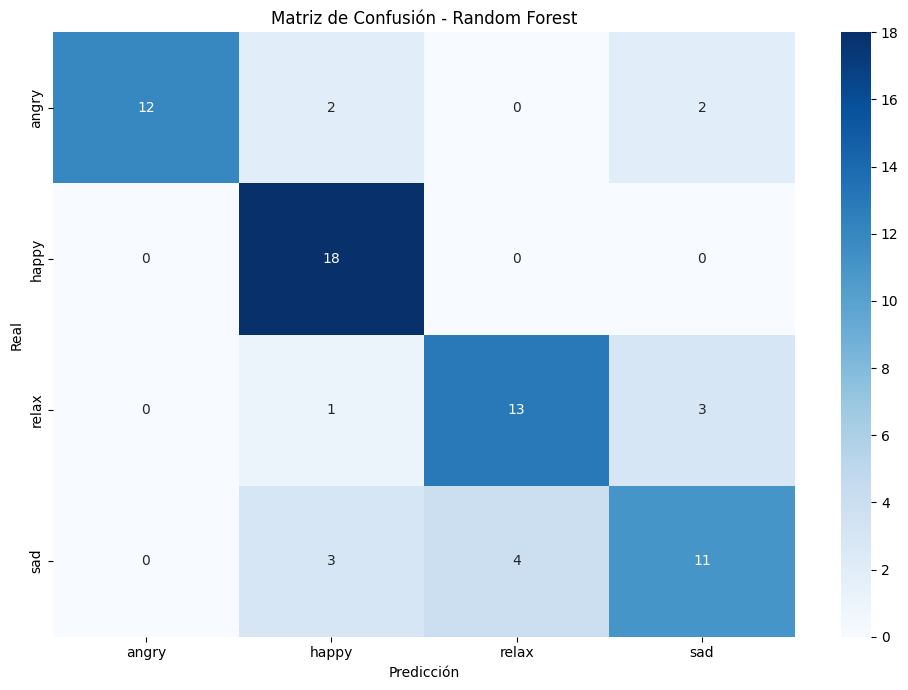

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Obtener los nombres de las clases originales
class_names = le.classes_

# Crear el gráfico de la matriz de confusión
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

# Etiquetas y título en español
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Random Forest')
plt.tight_layout()
plt.show()

In [ ]:
# Definir los parámetros del modelo
params = {
    "n_estimators": 100,
    "max_depth": 6,
    "min_samples_split": 10,
    "min_samples_leaf": 4,
    "bootstrap": True,
    "oob_score": False,
    "random_state": 42,
}

y_pred = model.predict(X_test)
